In [66]:
import pandas as pd
import string
import json
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

In [ ]:
# anew_w = pd.read_csv("../anew/anew.csv")
# anew_w = anew_w.drop(columns=["arousal", "dominance"])

# def similar_string(string):
#     similar = ["", "", 0]
#     for term in anew_w["term"].values:
#         similarity = SequenceMatcher(None, string, term).ratio()

#         if similarity > 0.7 and similarity > similar[2]:
#             similar = [term, string, similarity]
#             # print(similar)
    
#     return similar[0]

# def post_analyzer(text=str):
#     new_text = text.translate(
#         str.maketrans("", "", string.punctuation)
#     )
#     new_text = new_text.lower().split()

#     positive_w = []
#     p_sum = 0

#     negative_w = []
#     n_sum = 0

#     neutral_w = []

#     positive_score = 0
#     negative_score = 0

#     for word in new_text:
#         if not word in anew_w["term"].values:
#             word = similar_string(word)

#         if word and word in anew_w["term"].values:
#             element = anew_w[anew_w["term"] == word]
#             pleasure = element["pleasure"].iloc[0]

#             score = (pleasure - 50) / 50 * 10

#             if score > 0:
#                 p_sum += score
#                 positive_w.append((word, score))

#             elif score < 0:
#                 n_sum += score
#                 negative_w.append((word, score))

#             else:
#                 neutral_w.append((word, score))

#     # result = p_sum - (-n_sum)

#     if len(positive_w) > 0:
#         positive_score = p_sum / (len(positive_w) * 10)

#     if len(negative_w) > 0:
#         negative_score = -n_sum / (len(negative_w) * 10)

#     result = positive_score - negative_score

#     # print("Positive:", positive_w)
#     # print("Negative:", negative_w)
#     # print("Neutral:", neutral_w)

#     if result > 0:
#         return "Positive post"

#     elif result < 0:
#         return "Negative post"

#     return "Neutral post"

In [109]:
anew_w = pd.read_csv("../anew/anew.csv")
anew_w = anew_w.drop(columns=["arousal", "dominance"])

negators = {
    "not", "no", "never", "nothing", "none", "neither", "nor", "cannot", "cant",
    "dont", "doesnt", "didnt", "wasnt", "werent", "isnt", "arent", "wont",
    "wouldnt", "couldnt", "shouldnt", "without", "hardly", "barely", "rarely",
}

def post_analyzer(text=str):
    new_text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    new_text = new_text.lower().split()

    positive_w = []
    p_sum = 0

    negative_w = []
    n_sum = 0

    neutral_w = []

    positive_score = 0
    negative_score = 0
    
    for i in range(len(new_text)):
        word = new_text[i]
        negated = False

        if word and word in anew_w["term"].values:
            element = anew_w[anew_w["term"] == word]
            pleasure = element["pleasure"].iloc[0]

            score = (pleasure - 50) / 50 * 10

            if i > 0 and i < len(new_text) - 1:
                if new_text[i + 1] in negators or new_text[i - 1] in negators:
                    negated = True

            if not negated:
                if score > 0:
                    p_sum += score
                    positive_w.append((word, score))

                elif score < 0:
                    n_sum += score
                    negative_w.append((word, score))

                else:
                    neutral_w.append((word, score))

            else:
                if score < 0:
                    p_sum += score
                    positive_w.append(("!" + word, score))

                elif score > 0:
                    n_sum += score
                    negative_w.append(("!" + word, score))

                else:
                    neutral_w.append(("!" + word, score))

    # result = p_sum - (-n_sum)

    if len(positive_w) > 0:
        positive_score = p_sum / (len(positive_w) * 10)

    if len(negative_w) > 0:
        negative_score = -n_sum / (len(negative_w) * 10)

    result = positive_score - negative_score

    # print("Positive:", positive_w)
    # print("Negative:", negative_w)
    # print("Neutral:", neutral_w)

    if result > 0:
        return "Positive post"

    elif result < 0:
        return "Negative post"

    return "Neutral post"

In [110]:
text = '''
"I went into this movie excited to watch Supergirl, but somehow the film seemed far more interested in another character that was constantly pushed to the forefront. By the end, it felt like she was the actual protagonist while Supergirl had been reduced to a supporting role in her own movie.\n\nThis character is easily the most frustrating part of the film. Her dialogue is annoying, her performance never clicked with me, and the camera keeps returning to her so often that it becomes distracting. What's worse is that she doesn't have any meaningful character arc that justifies the amount of screen time she receives.\n\nThe screenplay is shockingly weak. Considering the budget and the talent involved, this should have been a far more entertaining and engaging film. Instead, it somehow manages to be dull, poorly paced, and emotionally flat. It's genuinely surprising that a movie with so many resources ended up feeling this underdeveloped.\n\nAs for Supergirl herself, she's actually one of the few bright spots. She has charisma, presence, and looks every bit the hero the movie should have focused on.\n\nUnfortunately, the lack of chemistry between the two leads drags the entire film down, and she simply isn't given enough material to carry the story by herself.\n\nThis is one of the most disappointing superhero movies I've seen in recent years. A strong lead performance can't save a film when the script is this weak and the focus is placed on all the wrong characters.",

'''

print(post_analyzer(text))

Positive post


In [111]:
analyze_result = {}

with open("../results/supergirl/imdb_tt8814476_reviews.json", "r", encoding="utf-8") as post_file:
    posts = json.load(post_file)

for post in posts["reviews"]:
    analyze_result[post["review_id"]] = post_analyzer(post["review"])

print(analyze_result)


{'rw11594246': 'Positive post', 'rw11596245': 'Positive post', 'rw11606552': 'Positive post', 'rw11611931': 'Positive post', 'rw11596945': 'Positive post', 'rw11728541': 'Positive post', 'rw11610872': 'Positive post', 'rw11616217': 'Positive post', 'rw11596399': 'Positive post', 'rw11599745': 'Positive post', 'rw11594206': 'Positive post', 'rw11598869': 'Positive post', 'rw11600498': 'Negative post', 'rw11598154': 'Negative post', 'rw11622560': 'Positive post', 'rw11593576': 'Positive post', 'rw11599939': 'Negative post', 'rw11619914': 'Positive post', 'rw11597392': 'Positive post', 'rw11708075': 'Positive post', 'rw11598880': 'Positive post', 'rw11596933': 'Positive post', 'rw11599398': 'Positive post', 'rw11599472': 'Positive post', 'rw11597168': 'Positive post', 'rw11598721': 'Positive post', 'rw11602136': 'Positive post', 'rw11595021': 'Positive post', 'rw11611952': 'Positive post', 'rw11621322': 'Positive post', 'rw11604219': 'Positive post', 'rw11598239': 'Positive post', 'rw1160

In [112]:
positive = 0
negative = 0
neutral = 0

for result in analyze_result:
    if analyze_result[result] == "Positive post":
        positive += 1

    elif analyze_result[result] == "Negative post":
        negative += 1

    else:
        neutral += 1

positive_per = positive/(positive + negative) * 100
negative_per = negative/(positive + negative) * 100
neutral_per = neutral/(positive + neutral) * 100

print(f"Positive posts: {positive_per:.2f}%")
print(f"Negative posts: {negative_per:.2f}%")
print(f"Neutral posts: {neutral_per:.2f}%")

Positive posts: 92.35%
Negative posts: 7.65%
Neutral posts: 0.65%


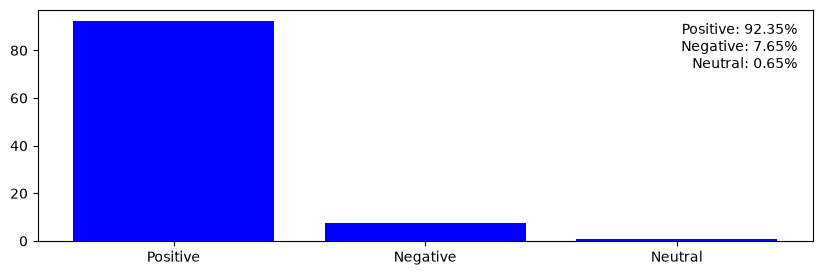

In [113]:
sentiments = ["Positive", "Negative", "Neutral"]
percentages = [positive_per, negative_per, neutral_per]

plt.figure(figsize=(10,3))
plt.bar(sentiments, percentages, color='blue', linewidth=1.3)

plt.text(
    0.98, 0.95,
    f"Positive: {positive_per:.2f}%\nNegative: {negative_per:.2f}%\nNeutral: {neutral_per:.2f}%",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)
plt.show()